# Gadget50 vs StePS-PDS50 — small-domain (50 Mpc) comparison

A small-box companion to `Gadget_vs_PDS_comparison.ipynb`. Two **256³, seed 137, 50 Mpc,
LCDM, z_start=31** runs, both with **glass ICs**:

- **Gadget50 (flat glass)** — `gadget50_glass`, flat T³ reference (Gadget4, PMGRID=256).
  Its glass is a 64³ Poisson cube relaxed in EdS, tiled 4³ → 256³.
- **PDS50 (glass)** — `test50glass`, curved S³/I\* with **R_curv = 3100/24 = 129.17 Mpc**
  (the flagship glass re-charted by exact scale invariance), + discrete S³/I\* modes (n=12,20).

**Why 50 Mpc is special.** At this box size the discrete topology modes fall at the very
largest scales: k₁₂ = 0.100 and k₂₀ = 0.162 /Mpc, versus the box fundamental k_box = 0.126.
So the box is **topology-dominated** — the S³/I\* eigenmodes *are* the large-scale structure
(unlike the 1200 Mpc runs where they are a sub-percent large-scale correction). This is a
deliberately unphysical test box to expose topology effects.

Contents: **(1)** density slices z=0, **(2)** density evolution, **(3)** power-spectrum
evolution, **(4)** P(k) ratio & growth, **(5)** flat-glass tiling signature.

> **Frames.** PDS in stereographic coords; Gadget shifted to the same origin by
> `x_matched = x_box − L/2` (= x_box − 25 Mpc; FFT-verified, and *not* `np.mod(x+L/2,L)−L/2`
> which is a no-op). P(k) uses a cube that fits inside the (scaled) dodecahedral domain
> (`HALF=13` Mpc, corner 22.5 < domain vertex 25.3). **Caveat unique to the small box:** the
> discrete modes (k≈0.10–0.16) lie *below* the fitting-cube fundamental (k_f = 0.24), so the
> fitting-cube P(k) probes only the **shared high-k flat band** — the topology signal is a
> box-scale effect, seen in §5 and in the separate stacking analysis (`/scratch/csabai/stack3d/`).

In [1]:
import numpy as np, h5py, os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.integrate import quad

# cosmology (shared, flat)
OM, OL, HUB = 0.3106, 0.6894, 0.67702
R_CURV  = 3100.0/24.0      # PDS curvature radius for the 50 Mpc runs [Mpc] = 129.1667
A_START = 1.0/32.0         # z = 31
LBOX    = 50.0             # box size [Mpc]

# P(k) analysis cube half-width [Mpc]. Must fit inside the scaled dodecahedral domain
# (verified 100% inside up to half=14; corner 13*sqrt(3)=22.5 < 25.3 Mpc domain vertex).
HALF = 13.0

RUNS = {
    'Gadget50 (flat glass)': dict(dir='/scratch/csabai/gadget50_glass', kind='gadget', w=3),
    'PDS50 (glass)':         dict(dir='/scratch/csabai/test50glass',     kind='pds',    w=4),
}
ZLIST  = [30,15,10,5,3,2,1,0.7,0.5,0.2,0]
IDX_OF = {z:i for i,z in enumerate(ZLIST)}

def Dgrow(a):
    I,_ = quad(lambda ap: 1.0/(ap*np.sqrt(OM/ap**3+OL))**3, 1e-8, a)
    return 2.5*OM*np.sqrt(OM/a**3+OL)*I
print('linear growth D(0)/D(31) =', round(Dgrow(1.0)/Dgrow(A_START), 2))
print('k_12 = %.3f, k_20 = %.3f, k_box = %.3f, k_fit-cube = %.3f /Mpc'
      % (np.sqrt(12*14)/R_CURV, np.sqrt(20*22)/R_CURV, 2*np.pi/LBOX, 2*np.pi/(2*HALF)))

linear growth D(0)/D(31) = 25.13
k_12 = 0.100, k_20 = 0.162, k_box = 0.126, k_fit-cube = 0.242 /Mpc


In [2]:
def load_phys(run, idx):
    # -> (positions in physical comoving Mpc, redshift)
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB                                   # Mpc/h -> Mpc (box frame [0,L])
    else:                                             # PDS: stereographic -> geodesic-normal
        r = np.sqrt((x**2).sum(1)); r = np.where(r < 1e-9, 1e-9, r)
        chi = 2.0*np.arctan2(r, R_CURV)
        x = (R_CURV*chi/r)[:, None]*x
    return x, z

# Matched frame: PDS stereographic (origin-centred); Gadget box -> matched by x/h - L/2.
# NOTE: np.mod(x+L/2,L)-L/2 is a no-op relabeling, NOT this shift (verified by FFT phase corr).
def load_for_gadget_match(run, idx):
    L = LBOX
    f = os.path.join(run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx))
    with h5py.File(f, 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
        z = float(h['Header'].attrs['Redshift'])
    if run['kind'] == 'gadget':
        x = x / HUB - L/2
    return x, z

def density_slice(x, half=13.0, slab=2.0, ng=220, smooth=1.1):
    x = x - np.median(x, 0)
    m = (np.abs(x[:,2])<slab) & (np.abs(x[:,0])<half) & (np.abs(x[:,1])<half)
    H2,_,_ = np.histogram2d(x[m,0], x[m,1], bins=ng, range=[[-half,half]]*2)
    return gaussian_filter(H2.T, smooth)

def power_spectrum(x, half=None, ng=64):
    if half is None: half = HALF
    x = x - np.median(x, 0)
    m = (np.abs(x)<half).all(1); xx = x[m]+half; L = 2*half; N = len(xx)
    idx = np.clip((xx/L*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (idx[:,0],idx[:,1],idx[:,2]), 1.0)
    d = g/g.mean()-1.0; Pk = np.abs(np.fft.fftn(d))**2 * L**3/ng**6
    kf = 2*np.pi/L
    kk = np.sqrt(sum(np.meshgrid(*[np.fft.fftfreq(ng,1/ng)**2]*3, indexing='ij')))*kf
    shot = L**3/N
    ks, Ps = [], []
    for q in range(1, ng//2):
        sel = (kk>=(q-0.5)*kf) & (kk<(q+0.5)*kf)
        if sel.sum()>0: ks.append(q*kf); Ps.append(Pk[sel].mean()-shot)
    return np.array(ks), np.array(Ps)

def clustering_pk(run, idx):
    x, _ = (load_for_gadget_match if run['kind'] == 'pds' else load_phys)(run, idx)
    return power_spectrum(x)

## 1. Density slices at z = 0
Central 26 Mpc region, 4 Mpc slab, matched frame (PDS stereographic, Gadget shifted −25 Mpc),
matched 256³ resolution. Unlike the 1200 Mpc pair (which matched halo-by-halo at corr≈0.84),
here the different large-scale/topology modes (below k≈0.16) and nonlinear evolution
**decorrelate** the two z=0 fields — they share the seed-137 *small-scale* phases but the
cosmic webs are only statistically similar. The printed correlation quantifies this.

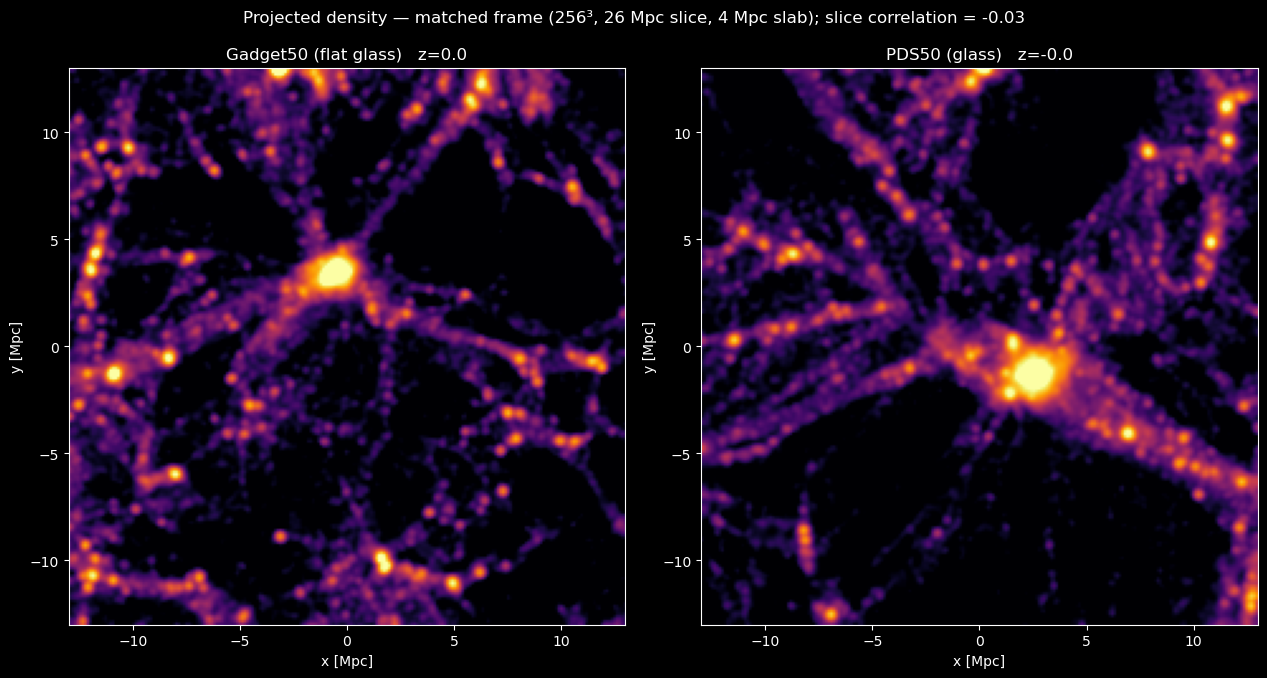

In [3]:
plt.style.use('dark_background')
fig, axes = plt.subplots(1, len(RUNS), figsize=(6.4*len(RUNS), 6.4))
dmaps = {}
for ax, (name, run) in zip(axes, RUNS.items()):
    x, z = load_for_gadget_match(run, IDX_OF[0])
    d = np.log10(density_slice(x)+0.5); dmaps[name] = d
    ax.imshow(d, origin='lower', extent=[-13,13,-13,13], cmap='inferno',
              vmin=np.percentile(d,40), vmax=np.percentile(d,99.7))
    ax.set_title('%s   z=%.1f' % (name, z), fontsize=12)
    ax.set_xlabel('x [Mpc]'); ax.set_ylabel('y [Mpc]')
a, b = list(dmaps.values())
cc = np.corrcoef(a.ravel(), b.ravel())[0,1]
fig.suptitle('Projected density — matched frame (256³, 26 Mpc slice, 4 Mpc slab); '
             'slice correlation = %.2f' % cc, y=1.02)
plt.tight_layout(); plt.show()

## 2. Matched-frame density evolution — PDS50 (top row) vs Gadget50 (bottom row)
Both runs in the **matched frame** (`load_for_gadget_match`: PDS stereographic, Gadget shifted
−L/2), so the columns show the *same* region. At **z=30 the two panels match** (they share the
IC field, correlation ≈ 0.9); then the box-scale topology modes drive divergent non-linear
growth and they **decorrelate** toward z=0 (correlation ≈ 0) — the visual counterpart of §4.

> ⚠️ Use `load_for_gadget_match`, **not** `load_phys`, for this comparison. `load_phys` maps the
> PDS to *geodesic-normal* coordinates (Ω≈2 stretch → structures ~2× larger, cluster pushed to
> the edge), which does **not** align with Gadget's box frame and makes the panels look
> unrelated even at z=30. `load_phys` is only for a *single-run* physical view.

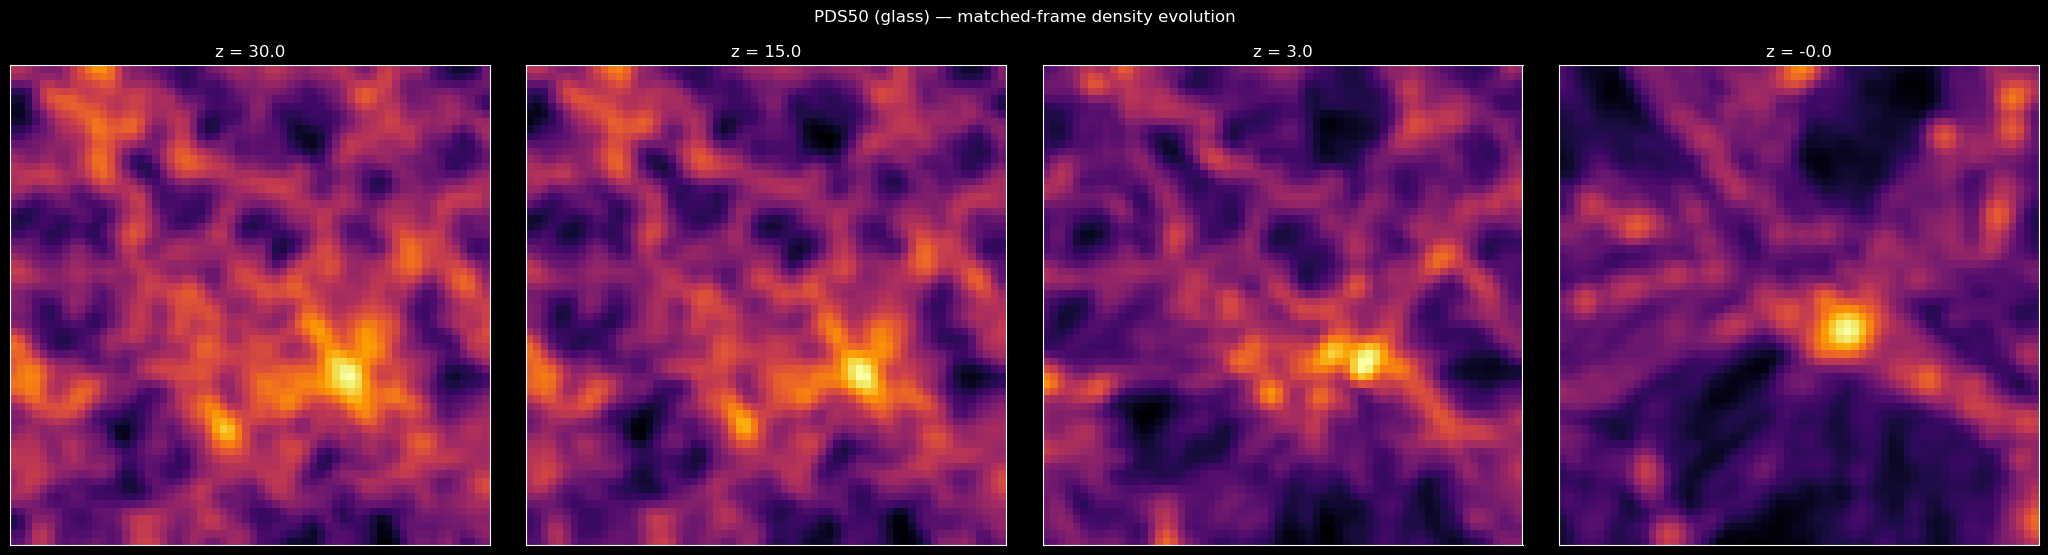

In [4]:
# PDS50 in the MATCHED frame (stereographic) -- compare column-by-column with Gadget50 below.
run = RUNS['PDS50 (glass)']
zs = [30, 15, 3, 0]
fig, axes = plt.subplots(1, len(zs), figsize=(5.2*len(zs), 5.4))
for ax, zz in zip(axes, zs):
    x, z = load_for_gadget_match(run, IDX_OF[zz]); d = density_slice(x, ng=64, smooth=1.0)
    ax.imshow(np.log10(d+0.5), origin='lower', extent=[-13,13,-13,13], cmap='inferno')
    ax.set_title('z = %.1f' % z); ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('PDS50 (glass) — matched-frame density evolution', y=1.02)
plt.tight_layout(); plt.show()

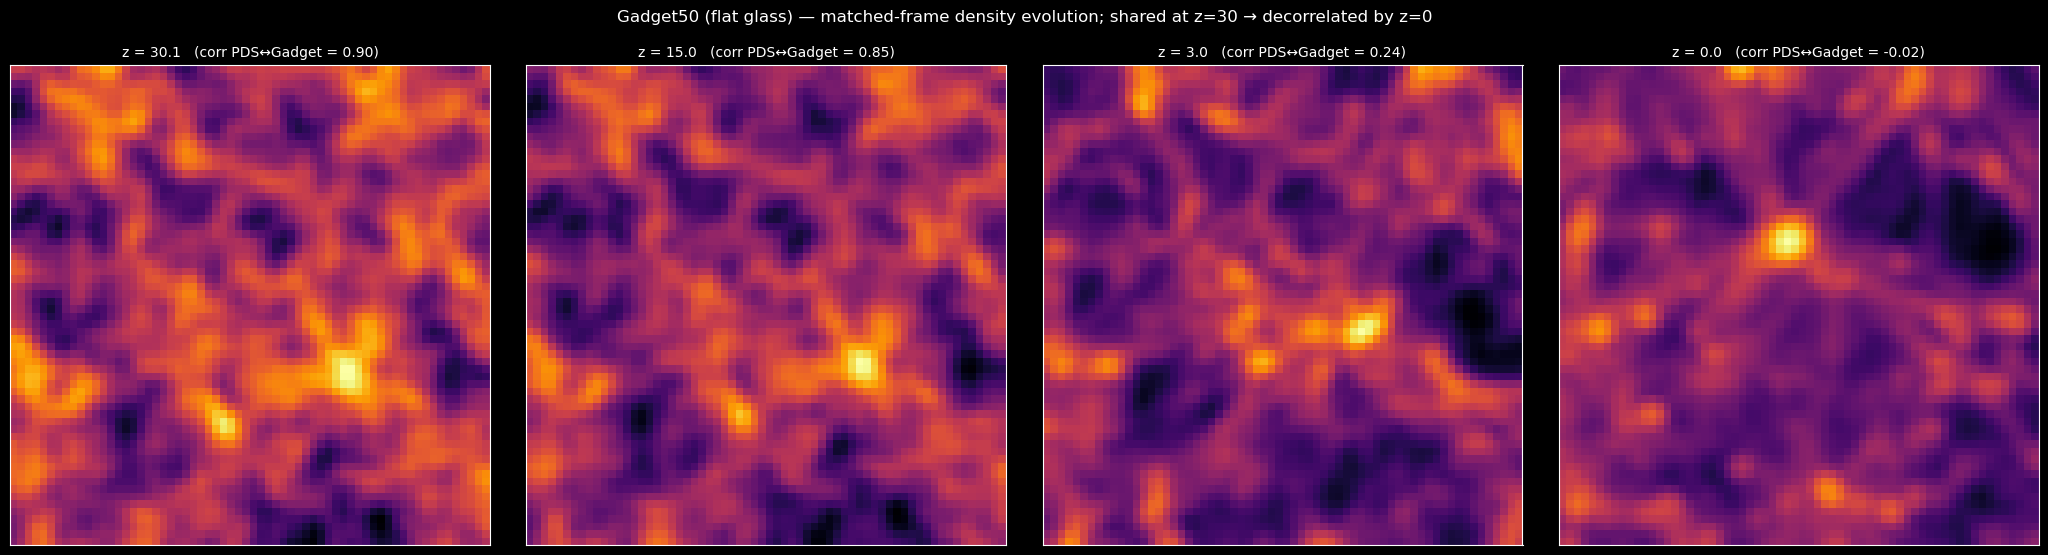

slice correlation PDS50 vs Gadget50 (matched frame): [(30.14519068126773, np.float64(0.9)), (15.04338040080324, np.float64(0.85)), (2.978397693934533, np.float64(0.24)), (0.0, np.float64(-0.02))]


In [5]:
# Gadget50 in the MATCHED frame -- same columns/region as the PDS50 row above.
# At z=30 the two rows match (shared IC); by z=0 they decorrelate (topology-driven growth).
run = RUNS['Gadget50 (flat glass)']
zs = [30, 15, 3, 0]
fig, axes = plt.subplots(1, len(zs), figsize=(5.2*len(zs), 5.4))
cc = []
for ax, zz in zip(axes, zs):
    xg, z = load_for_gadget_match(run, IDX_OF[zz]);        dg = density_slice(xg, ng=64, smooth=1.0)
    xp, _ = load_for_gadget_match(RUNS['PDS50 (glass)'], IDX_OF[zz]); dp = density_slice(xp, ng=64, smooth=1.0)
    ax.imshow(np.log10(dg+0.5), origin='lower', extent=[-13,13,-13,13], cmap='inferno')
    r = np.corrcoef(dg.ravel(), dp.ravel())[0,1]; cc.append((z, r))
    ax.set_title('z = %.1f   (corr PDS↔Gadget = %.2f)' % (z, r), fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle('Gadget50 (flat glass) — matched-frame density evolution; '
             'shared at z=30 → decorrelated by z=0', y=1.02)
plt.tight_layout(); plt.show()
print('slice correlation PDS50 vs Gadget50 (matched frame):', [(z, round(r,2)) for z, r in cc])

## 3. Power-spectrum evolution
Raw P(k) (shot-noise subtracted) at z = 10, 5, 2, 0, in the fitting cube (`HALF=13` Mpc).
Because the cube is fully inside the domain there is **no window pedestal / no subtraction**.
The dashed line is a smooth Eisenstein-Hu linear reference anchored to Gadget50's z=0 large
scales. **Note:** k_f ≈ 0.24 /Mpc here, above the discrete modes (0.10–0.16), so these panels
show only the flat band that the two ICs share — but see §4: even here PDS50 develops
**more** small-scale power by z=0, driven from the (unshared) topology-dominated large scales.

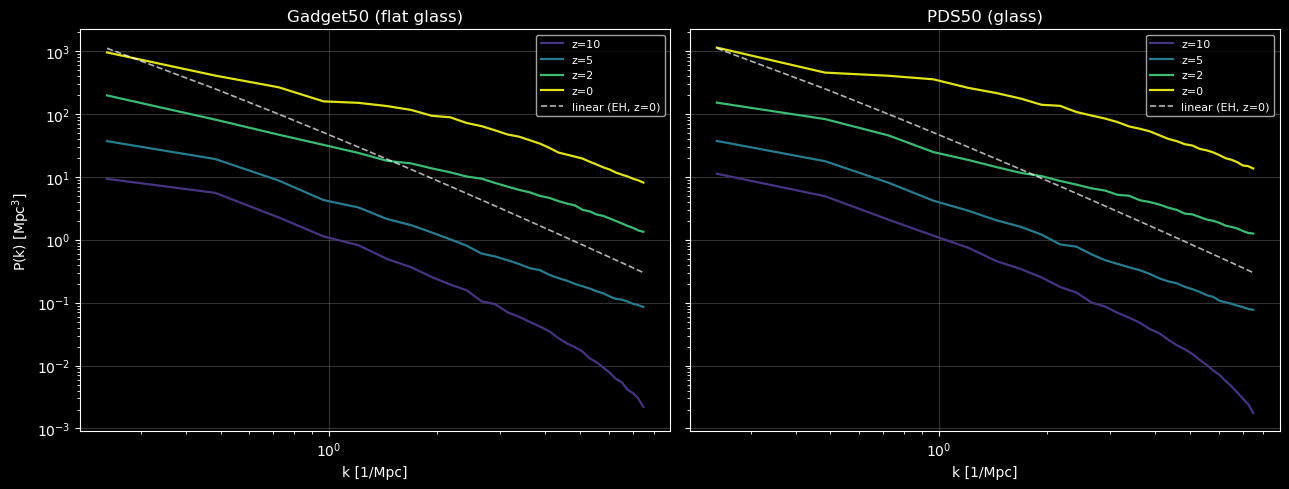

In [6]:
def Pk_lin_EH(k, Om0=OM, Ob0=0.0486, h=HUB, ns=0.9665, Tcmb=2.7255):
    theta = Tcmb/2.7; omh2 = Om0*h*h; obh2 = Ob0*h*h
    s = 44.5*np.log(9.83/omh2)/np.sqrt(1+10*obh2**0.75)
    a = 1 - 0.328*np.log(431*omh2)*(Ob0/Om0) + 0.38*np.log(22.3*omh2)*(Ob0/Om0)**2
    Geff = Om0*h*(a + (1-a)/(1+(0.43*k*s)**4))
    q = (k/h)*theta**2/Geff
    C0 = 14.2 + 731.0/(1+62.5*q); L0 = np.log(2*np.e + 1.8*q)
    T = L0/(L0 + C0*q*q)
    return k**ns * T**2

z_show = [10, 5, 2, 0]
colors = plt.cm.viridis(np.linspace(0.15, 0.95, len(z_show)))
fig, axes = plt.subplots(1, len(RUNS), figsize=(6.5*len(RUNS), 5), sharex=True, sharey=True)
pk_cache = {}
gname = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
kg0, Pg0 = clustering_pk(RUNS[gname], IDX_OF[0])
Plin = Pk_lin_EH(kg0); anc = kg0 < 0.5
Plin *= np.nanmean(Pg0[anc]) / np.nanmean(Plin[anc])
for ax, (name, run) in zip(axes, RUNS.items()):
    for z, c in zip(z_show, colors):
        k, P = clustering_pk(run, IDX_OF[z]); pk_cache[(name, z)] = (k, P)
        ok = P > 0; ax.loglog(k[ok], P[ok], color=c, lw=1.6, label='z=%g' % z)
    ax.loglog(kg0, Plin, 'w--', lw=1.2, alpha=0.7, label='linear (EH, z=0)')
    ax.set_title(name); ax.set_xlabel('k [1/Mpc]'); ax.grid(alpha=0.2); ax.legend(fontsize=8)
axes[0].set_ylabel('P(k) [Mpc$^3$]')
plt.tight_layout(); plt.show()

## 4. P(k) ratio and growth
Left: PDS50 / Gadget50 P(k) ratio at z=0. Unlike the 1200 Mpc runs (ratio ≈ 1 across the
resolved band), here PDS50 carries a **~1.6× small-scale excess**. It is *dynamical, not a
sampling artifact*: the ratio is ~1.0–1.3 at the IC (z=30, with matched shot noise), dips to
~0.9 at z=5, then climbs to ~1.55 by z=0 — i.e. the topology-dominated large-scale modes
(which the fitting cube cannot see directly) seed **stronger non-linear collapse** that
cascades into the shared small-scale band. This is the P(k) counterpart of the more contrasted,
anisotropic PDS50 web in §1. Right: growth of the low-k P(k) amplitude vs linear D(a)²; at
50 Mpc the box is strongly non-linear at low z, so both runs depart from linear growth early,
PDS50 slightly later at low z.

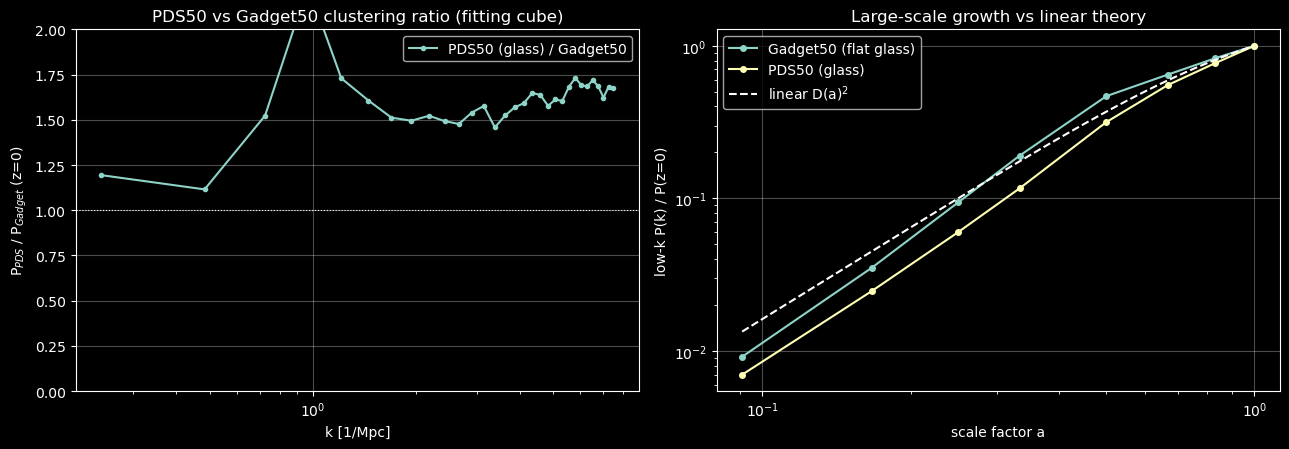

In [7]:
fig, (axr, axg) = plt.subplots(1, 2, figsize=(13, 4.6))
gname     = next(n for n, r in RUNS.items() if r['kind'] == 'gadget')
pds_names = [n for n, r in RUNS.items() if r['kind'] == 'pds']
kg, Pg = pk_cache[(gname, 0)]
for name in pds_names:
    kp, Pp = pk_cache[(name, 0)]; n = min(len(Pg), len(Pp))
    r = Pp[:n]/np.where(Pg[:n] > 0, Pg[:n], np.nan)
    axr.semilogx(kg[:n], r, marker='o', ms=3, label=name + ' / Gadget50')
axr.axhline(1, color='w', lw=0.8, ls=':'); axr.set_ylim(0, 2)
axr.set_xlabel('k [1/Mpc]'); axr.set_ylabel('P$_{PDS}$ / P$_{Gadget}$ (z=0)')
axr.legend(); axr.grid(alpha=0.3); axr.set_title('PDS50 vs Gadget50 clustering ratio (fitting cube)')
zs = [10, 5, 3, 2, 1, 0.5, 0.2, 0]
for name, run in RUNS.items():
    amp = []
    for z in zs:
        if (name, z) in pk_cache: k, P = pk_cache[(name, z)]
        else: k, P = clustering_pk(run, IDX_OF[z])
        nlow = max(1, len(P)//4); amp.append(np.nanmean(np.where(P[:nlow] > 0, P[:nlow], np.nan)))
    amp = np.array(amp); a = np.array([1/(1+z) for z in zs])
    axg.loglog(a, amp/amp[-1], marker='o', ms=4, label=name)
aa = np.linspace(1/11.0, 1, 50)
axg.loglog(aa, (np.array([Dgrow(x) for x in aa])/Dgrow(1.0))**2, 'w--', label='linear D(a)$^2$')
axg.set_xlabel('scale factor a'); axg.set_ylabel('low-k P(k) / P(z=0)')
axg.legend(); axg.grid(alpha=0.3); axg.set_title('Large-scale growth vs linear theory')
plt.tight_layout(); plt.show()

## 5. Flat-glass tiling signature
The flat run's glass was built by tiling a relaxed 64³ cube **4³ times** (period 12.5 Mpc) —
a standard but imperfect way to make a periodic glass. That leaves faint power at the tile
reciprocal vectors (k = 2π/12.5 = 0.503 /Mpc and multiples). We measure, in the **full 50 Mpc
box**, the median P(k) at the tile harmonics relative to their non-harmonic neighbours, versus
redshift. The **untiled PDS glass** is the control (no tiling → ratio ≈ 1). This is the
50 Mpc analogue of the grid-IC Bragg panel: a load artifact that is mild and washes out.

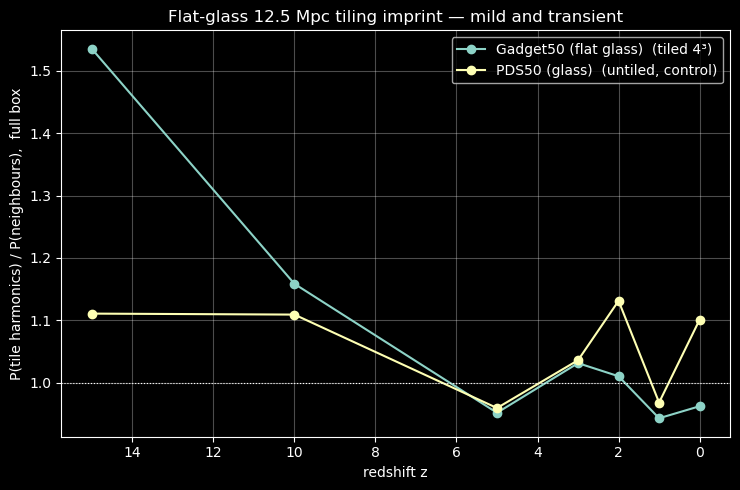

In [8]:
def tile_ratio(run, idx, ng=100, tile=12.5):
    # full-box density; ratio of P at tile reciprocal harmonics vs non-harmonic neighbours.
    d, fmt = run['dir'], 'snapshot_%0*d.hdf5' % (run['w'], idx)
    with h5py.File(os.path.join(d, fmt), 'r') as h:
        x = h['PartType1/Coordinates'][:].astype(np.float64)
    if run['kind'] == 'gadget': x = x / HUB          # box frame (tiling axis-aligned here)
    x = np.mod(x, LBOX)
    ix = np.clip((x/LBOX*ng).astype(int), 0, ng-1)
    g = np.zeros((ng,)*3); np.add.at(g, (ix[:,0], ix[:,1], ix[:,2]), 1.0)
    F = np.abs(np.fft.rfftn(g/g.mean()-1.0))**2
    step = int(round(LBOX/tile))                     # harmonic index spacing (=4)
    harm, near = [], []
    for i in range(0, ng//4+1, step):
        for j in range(0, ng//4+1, step):
            for k in range(0, ng//4+1, step):
                if i==j==k==0: continue
                harm.append(F[i,j,k])
                if i+1 < F.shape[0]: near.append(F[i+1,j,k])
    return np.median(harm)/np.median(near)

ztrack = [15, 10, 5, 3, 2, 1, 0]
fig, ax = plt.subplots(figsize=(7.5, 5))
for name, run in RUNS.items():
    ax.plot(ztrack, [tile_ratio(run, IDX_OF[z]) for z in ztrack], marker='o',
            label=name + ('  (tiled 4³)' if run['kind']=='gadget' else '  (untiled, control)'))
ax.axhline(1, color='w', ls=':', lw=0.8)
ax.invert_xaxis(); ax.set_xlabel('redshift z')
ax.set_ylabel('P(tile harmonics) / P(neighbours),  full box')
ax.set_title('Flat-glass 12.5 Mpc tiling imprint — mild and transient')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Caveats / interpretation
- **Topology-dominated box (by design).** With k₁₂=0.10 and k₂₀=0.16 /Mpc near/below k_box=0.126,
  the discrete S³/I\* eigenmodes are the largest modes present, so PDS50 is *not* a realistic
  universe — it maximises topology effects. The two ICs share only the small-scale (k ≳ 0.16)
  flat glass field and differ entirely on large scales (§1 slice correlation ≈ 0).
- **The topology feeds the small scales non-linearly.** Even though the fitting cube sees only
  the shared band, PDS50 ends up ~1.6× more clustered there by z=0 (§4) — the dominant discrete
  large-scale modes drive extra collapse. So in this small box the topology is not confined to
  large scales; it reshapes the whole field. (In the realistic 1200 Mpc box this does not
  happen — there the PDS runs match Gadget to ~few %.)
- **Fitting-cube P(k) cannot see the topology directly.** The domain limits the cube to
  HALF ≤ 14 Mpc (k_f ≥ 0.24), above the discrete modes. The direct topology signal is a
  box-scale / directional effect — quantified in the octahedral halo-stacking analysis
  (`/scratch/csabai/stack3d/`), where PDS50 shows a strong axis-locked (2-fold-axis) anisotropy
  after the S³/I\* wraparound correction, while the flat run does not.
- **Flat-glass tiling** (§5) is the one load compromise of the flat run; it is weak (~1.5× at
  the tile harmonics at z=15) and gone by z=0.
- **Frame:** PDS stereographic (origin), Gadget shifted −L/2. Geodesic-normal map used only for
  the §2 single-run physical view. Background flat in both (Ω_m+Ω_Λ=1).
- Single realization; masses are counts-based here (mass units irrelevant to slices/P(k)).